In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\python\Machine learning\Logistic_Regression_Assignment\heart_failure_clinical_records_dataset.csv")
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [3]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.shape

(299, 13)

In [6]:
df.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

In [7]:
# -----------------------------
# 3. Data Overview
# -----------------------------

In [8]:
df.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [10]:
# -----------------------------
# 5. Distribution & Outlier Analysis
# -----------------------------

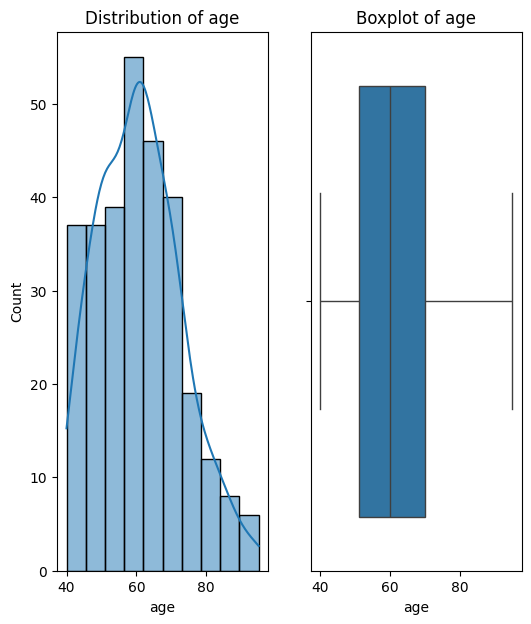

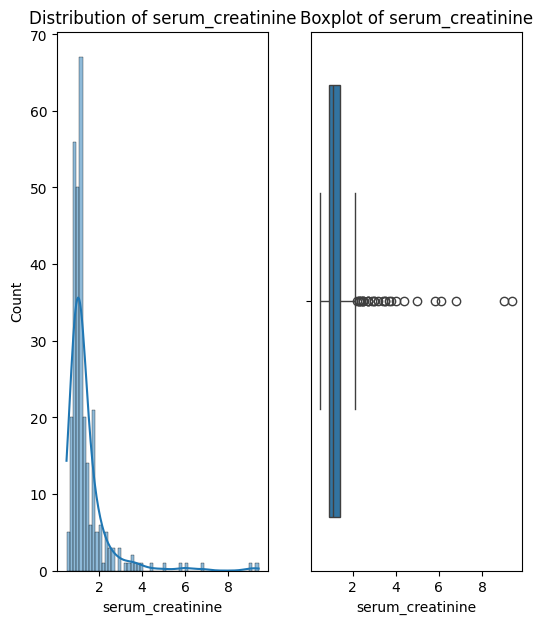

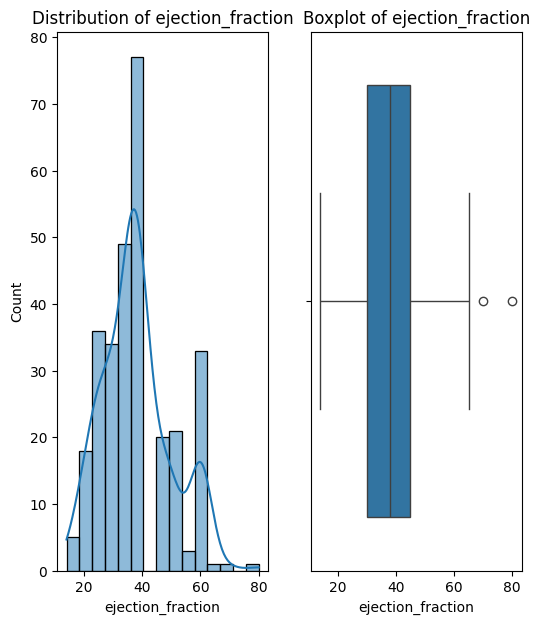

In [11]:
num_feature=['age',"serum_creatinine","ejection_fraction"]

for col in num_feature:
    plt.figure(figsize=(6,7))

    plt.subplot(1,2,1)
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of {col}")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()
    


# -----------------------------
# 6. Numerical Features vs Target
# -----------------------------

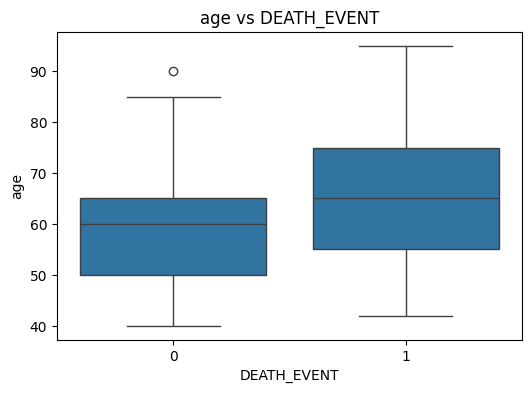

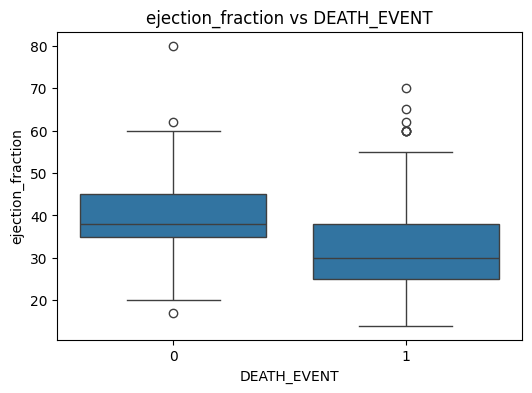

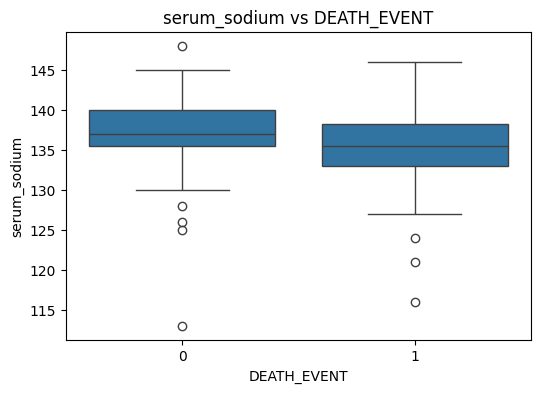

In [12]:
binery_relation_feature=['age',"ejection_fraction","serum_sodium"]

for col in binery_relation_feature:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="DEATH_EVENT", y=col,data=df)
    plt.title(f"{col} vs DEATH_EVENT")
    plt.show()


# -----------------------------
# 7. Categorical Feature Analysis
# -----------------------------

In [13]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


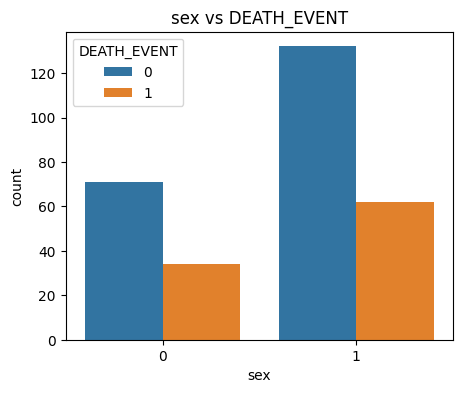

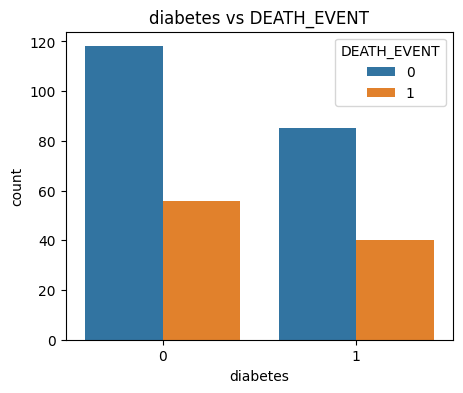

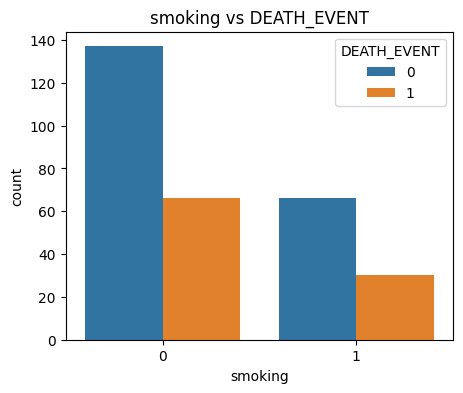

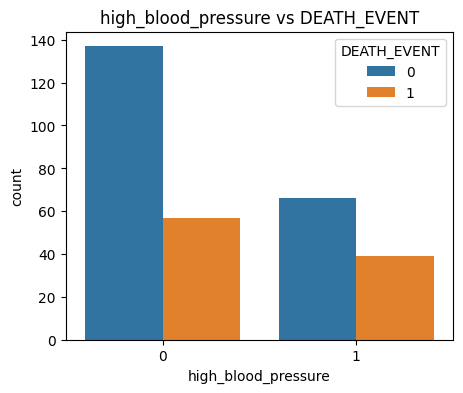

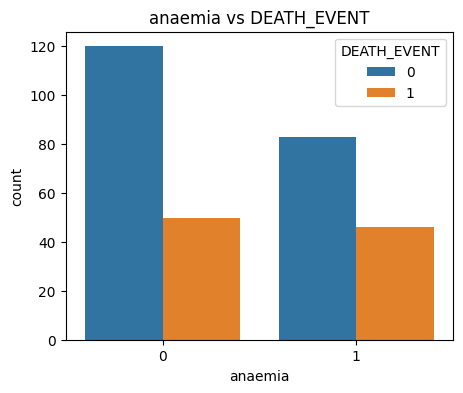

In [14]:
cat_feature=["sex", "diabetes", "smoking", "high_blood_pressure", "anaemia"]

for col in cat_feature:
    plt.figure(figsize=(5,4))
    sns.countplot(x=col,hue="DEATH_EVENT",data=df)
    plt.title(f"{col} vs DEATH_EVENT")
    plt.show()


In [15]:
# -----------------------------
# 8. Group Analysis (Age Groups)
# -----------------------------


Death Rate by Age group 
age_group
<=50     0.256757
51-65    0.284091
>65      0.379562
Name: DEATH_EVENT, dtype: float64


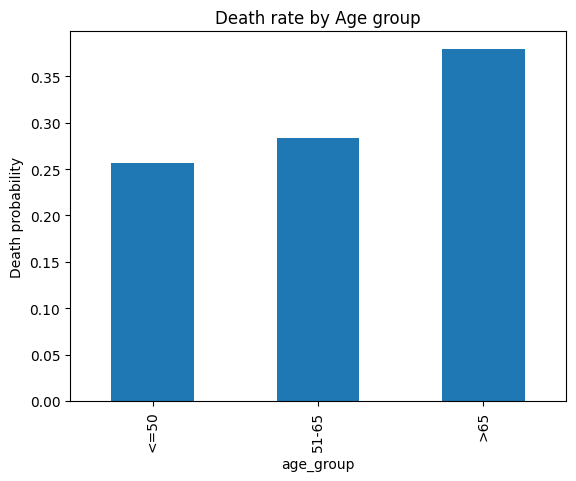

In [16]:
df['age_group']=pd.cut(
    df['age'],
    bins=[0,50,60,100],
    labels=['<=50','51-65','>65']
)
age_group_depth=df.groupby('age_group')['DEATH_EVENT'].mean()
print("\nDeath Rate by Age group ")
print(age_group_depth)

age_group_depth.plot(kind='bar',title="Death rate by Age group")
plt.ylabel("Death probability")
plt.show()


In [21]:
# Correlation Analysis

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: '>65'

<Figure size 1000x800 with 0 Axes>

In [22]:
# model Building

x=df.drop(["DEATH_EVENT", "age_group"],axis=1)
y=df['DEATH_EVENT']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)


In [25]:
# 11Feature scalling

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [26]:
# 12 Logistic Regression model

model=LogisticRegression()
model.fit(x_train_scaled,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
#  13 Model Evaluation

y_pred=model.predict(x_test_scaled)
y_prob=model.predict_proba(x_test_scaled)[:,1]

In [38]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test,y_pred))


Confusion Matrix:

[[38  3]
 [ 8 11]]


In [39]:
roc_auc=roc_auc_score(y_test,y_prob)
print("Roc-AUC score:",roc_auc)

Roc-AUC score: 0.858793324775353


In [41]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.93      0.87        41
           1       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60



In [42]:
roc_auc=roc_auc_score(y_test,y_prob)
print("Roc-AUC score:",roc_auc)

Roc-AUC score: 0.858793324775353


In [ ]:
# -----------------------------
# 14. ROC Curve
# -----------------------------

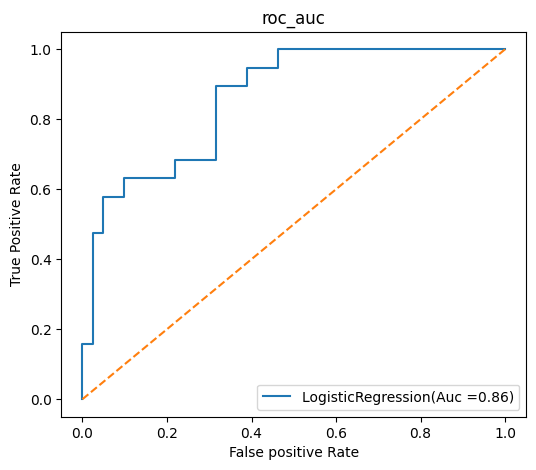

In [44]:
fpr,tpr,threshold=roc_curve(y_test,y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f"LogisticRegression(Auc ={roc_auc:.2f})")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False positive Rate")
plt.ylabel("True Positive Rate")
plt.title("roc_auc")
plt.legend()
plt.show()

In [46]:
# 15 Feature Importamce Cofficients

coff_df=pd.DataFrame({
    'feature':x.columns,
    'cofficient':model.coef_[0]
}).sort_values(by="cofficient",ascending=False)

print("\nLogistic Regression cofficient :\n")
print(coff_df)


Logistic Regression cofficient :

                     feature  cofficient
7           serum_creatinine    0.787676
0                        age    0.416343
2   creatinine_phosphokinase    0.275913
3                   diabetes    0.242201
10                   smoking    0.111317
1                    anaemia    0.090645
5        high_blood_pressure    0.049263
8               serum_sodium   -0.137449
6                  platelets   -0.139808
9                        sex   -0.200936
4          ejection_fraction   -0.909601
11                      time   -1.577011


In [47]:
# for threshold
j=tpr-fpr
vth=threshold[j.argmax()]

new_y_pred=list(map(lambda x:1 if x>vth else 0,y_prob))
print(confusion_matrix(y_test,new_y_pred))
print(classification_report(y_test,new_y_pred))

[[28 13]
 [ 3 16]]
              precision    recall  f1-score   support

           0       0.90      0.68      0.78        41
           1       0.55      0.84      0.67        19

    accuracy                           0.73        60
   macro avg       0.73      0.76      0.72        60
weighted avg       0.79      0.73      0.74        60

